In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os, json
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train = np.load('../data/processed/X_train.npy')
X_val   = np.load('../data/processed/X_val.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val   = np.load('../data/processed/y_val.npy')
y_test  = np.load('../data/processed/y_test.npy')
snr_train = np.load('../data/processed/snr_train.npy')
snr_val   = np.load('../data/processed/snr_val.npy')
snr_test  = np.load('../data/processed/snr_test.npy')

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}, snr_train: {snr_train.shape}")

Using device: cuda
X_train: (154000, 2, 128), y_train: (154000,), snr_train: (154000,)


In [2]:
class RadioMLDatasetSNR(Dataset):
    def __init__(self, X, y, snr):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
        self.snr = torch.from_numpy(snr).float()  

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.snr[idx]

train_dataset = RadioMLDatasetSNR(X_train, y_train, snr_train)
val_dataset   = RadioMLDatasetSNR(X_val, y_val, snr_val)
test_dataset  = RadioMLDatasetSNR(X_test, y_test, snr_test)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

sample_X, sample_y, sample_snr = next(iter(train_loader))
print(f"Batch X shape: {sample_X.shape}")
print(f"Batch y shape: {sample_y.shape}")
print(f"Batch snr shape: {sample_snr.shape}")
print(f"Sample SNR values: {sample_snr[:5]}")

Batch X shape: torch.Size([64, 2, 128])
Batch y shape: torch.Size([64])
Batch snr shape: torch.Size([64])
Sample SNR values: tensor([ 12.,  18., -12.,  16.,  -2.])


In [3]:
class SNRAwareFiLMModel(nn.Module):
    def __init__(self, num_classes=11):
        super(SNRAwareFiLMModel, self).__init__()

        # --- Shared CNN feature extractor ---
        self.conv1 = nn.Conv1d(2, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()

        # --- BiLSTM ---
        self.lstm = nn.LSTM(input_size=64, hidden_size=64, num_layers=1,
                            batch_first=True, bidirectional=True)

        # --- SNR Estimator branch ---
        self.snr_conv1 = nn.Conv1d(2, 32, kernel_size=3, padding=1)
        self.snr_gn1 = nn.GroupNorm(num_groups=8, num_channels=32)
        self.snr_conv2 = nn.Conv1d(32, 32, kernel_size=3, padding=1)
        self.snr_gn2 = nn.GroupNorm(num_groups=8, num_channels=32)
        self.snr_pool = nn.AdaptiveAvgPool1d(1)
        self.snr_fc = nn.Linear(32, 1)

        # --- FiLM generator: SNR scalar -> (gamma, beta) for 128 channels ---
        self.film = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 128 * 2)   # 128 gammas + 128 betas
        )

        # --- Attention (standard now, SNR acts via FiLM instead) ---
        self.attn_fc = nn.Linear(128, 1)

        # --- Classifier ---
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def estimate_snr(self, x):
        s = self.relu(self.snr_gn1(self.snr_conv1(x)))
        s = self.relu(self.snr_gn2(self.snr_conv2(s)))
        s = self.snr_pool(s).squeeze(-1)
        return torch.tanh(self.snr_fc(s))         # (batch, 1), bounded [-1, 1]

    def apply_film(self, lstm_out, snr_est):
        # lstm_out: (batch, seq_len, 128); snr_est: (batch, 1)
        params = self.film(snr_est)                       # (batch, 256)
        gamma, beta = params.chunk(2, dim=-1)             # each (batch, 128)
        gamma = gamma.unsqueeze(1)                        # (batch, 1, 128) -> broadcasts over time
        beta = beta.unsqueeze(1)
        # (1 + gamma) so that gamma=0 means "leave features unchanged" at init
        return (1 + gamma) * lstm_out + beta

    def attention(self, feats):
        attn_scores = self.attn_fc(feats)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = torch.sum(attn_weights * feats, dim=1)
        return context, attn_weights

    def forward(self, x):
        snr_est = self.estimate_snr(x)

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.pool(out)
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.pool(out)

        out = out.permute(0, 2, 1)
        lstm_out, _ = self.lstm(out)                      # (batch, seq_len, 128)

        modulated = self.apply_film(lstm_out, snr_est)    # SNR reshapes the features here

        context, attn_weights = self.attention(modulated)

        out = self.dropout(self.relu(self.fc1(context)))
        class_logits = self.fc2(out)

        return class_logits, snr_est

model = SNRAwareFiLMModel(num_classes=11).to(device)
print("FiLM model built")

dummy_input = torch.randn(4, 2, 128).to(device)
c, s = model(dummy_input)
print(f"Class output: {c.shape} | SNR output: {s.shape} | SNR range: [{s.min():.3f}, {s.max():.3f}]")

FiLM model built
Class output: torch.Size([4, 11]) | SNR output: torch.Size([4, 1]) | SNR range: [0.104, 0.130]


In [4]:
SNR_MIN = -20.0
SNR_MAX = 18.0
SNR_MEAN = (SNR_MAX + SNR_MIN) / 2.0   #-1.0
SNR_SCALE = (SNR_MAX - SNR_MIN) / 2.0  #19.0

def normalize_snr(snr):
    return (snr - SNR_MEAN) / SNR_SCALE

def denormalize_snr(snr_norm):
    return snr_norm * SNR_SCALE + SNR_MEAN

print(f"Check: -20 dB -> {normalize_snr(torch.tensor(-20.0)):.3f}")
print(f"Check:  18 dB -> {normalize_snr(torch.tensor(18.0)):.3f}")
print(f"Check:   0 dB -> {normalize_snr(torch.tensor(0.0)):.3f}")

Check: -20 dB -> -1.000
Check:  18 dB -> 1.000
Check:   0 dB -> 0.053


In [16]:
criterion_class = nn.CrossEntropyLoss()
criterion_snr = nn.MSELoss()
lambda_snr = 0.1

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs = 20
best_val_acc = 0.0

train_losses = []
val_losses = []
val_accuracies = []
val_snr_maes = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch, snr_batch in train_loader:
        X_batch, y_batch, snr_batch = X_batch.to(device), y_batch.to(device), snr_batch.to(device)
        snr_target = normalize_snr(snr_batch)    

        optimizer.zero_grad()
        class_logits, snr_pred = model(X_batch)

        loss_class = criterion_class(class_logits, y_batch)
        loss_snr = criterion_snr(snr_pred.squeeze(), snr_target)
        loss = loss_class + lambda_snr * loss_snr

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0
    snr_abs_errors = []
    with torch.no_grad():
        for X_batch, y_batch, snr_batch in val_loader:
            X_batch, y_batch, snr_batch = X_batch.to(device), y_batch.to(device), snr_batch.to(device)
            snr_target = normalize_snr(snr_batch)

            class_logits, snr_pred = model(X_batch)

            loss_class = criterion_class(class_logits, y_batch)
            loss_snr = criterion_snr(snr_pred.squeeze(), snr_target)
            loss = loss_class + lambda_snr * loss_snr
            val_running_loss += loss.item() * X_batch.size(0)

            _, predicted = torch.max(class_logits, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            snr_pred_db = denormalize_snr(snr_pred.squeeze())
            snr_abs_errors.extend((snr_pred_db - snr_batch).abs().cpu().numpy())

    epoch_val_loss = val_running_loss / len(val_dataset)
    epoch_val_acc = correct / total
    epoch_snr_mae = np.mean(snr_abs_errors)

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    val_snr_maes.append(epoch_snr_mae)

    scheduler.step(epoch_val_loss)

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), '../results/best_snr_aware_model.pt')
        marker = " <- saved (best so far)"
    else:
        marker = ""

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f} | SNR MAE: {epoch_snr_mae:.2f} dB | LR: {current_lr:.6f}{marker}")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 1/20 | Train Loss: 1.4338 | Val Loss: 1.2748 | Val Acc: 0.4882 | SNR MAE: 5.14 dB | LR: 0.001000 <- saved (best so far)
Epoch 2/20 | Train Loss: 1.2533 | Val Loss: 1.2822 | Val Acc: 0.5099 | SNR MAE: 4.91 dB | LR: 0.001000 <- saved (best so far)
Epoch 3/20 | Train Loss: 1.2227 | Val Loss: 1.2025 | Val Acc: 0.5329 | SNR MAE: 5.85 dB | LR: 0.001000 <- saved (best so far)
Epoch 4/20 | Train Loss: 1.2021 | Val Loss: 1.2077 | Val Acc: 0.5372 | SNR MAE: 4.87 dB | LR: 0.001000 <- saved (best so far)
Epoch 5/20 | Train Loss: 1.1803 | Val Loss: 1.2814 | Val Acc: 0.5185 | SNR MAE: 6.59 dB | LR: 0.001000
Epoch 6/20 | Train Loss: 1.1661 | Val Loss: 1.1905 | Val Acc: 0.5495 | SNR MAE: 4.69 dB | LR: 0.001000 <- saved (best so far)
Epoch 7/20 | Train Loss: 1.1561 | Val Loss: 1.1752 | Val Acc: 0.5537 | SNR MAE: 4.58 dB | LR: 0.001000 <- saved (best so far)
Epoch 8/20 | Train Loss: 1.1457 | Val Loss: 1.2222 | Val Acc: 0.5393 | SNR MAE: 4.75 dB | LR: 0.001000
Epoch 9/20 | Train Loss: 1.1395 | Val 

In [17]:
import json

film_history = {
    'train_losses': [float(x) for x in train_losses],
    'val_losses': [float(x) for x in val_losses],
    'val_accuracies': [float(x) for x in val_accuracies],
    'val_snr_maes': [float(x) for x in val_snr_maes],
    'best_val_acc': float(best_val_acc)
}

with open('../results/snr_aware_film_history.json', 'w') as f:
    json.dump(film_history, f, indent=2)

print("Saved FiLM training history")

Saved FiLM training history


In [5]:
model.load_state_dict(torch.load('../results/best_snr_aware_model.pt'))
print("Loaded saved FiLM weights")

criterion_class = nn.CrossEntropyLoss()
criterion_snr = nn.MSELoss()
lambda_snr = 0.1

with open('../results/snr_aware_film_history.json', 'r') as f:
    hist = json.load(f)

train_losses = hist['train_losses']
val_losses = hist['val_losses']
val_accuracies = hist['val_accuracies']
val_snr_maes = hist['val_snr_maes']

print(f"Restored history: {len(train_losses)} epochs, best val acc {hist['best_val_acc']:.4f}")

Loaded saved FiLM weights
Restored history: 20 epochs, best val acc 0.5939


In [6]:
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs = 15
best_val_acc = 0.5939

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch, snr_batch in train_loader:
        X_batch, y_batch, snr_batch = X_batch.to(device), y_batch.to(device), snr_batch.to(device)
        snr_target = normalize_snr(snr_batch)

        optimizer.zero_grad()
        class_logits, snr_pred = model(X_batch)
        loss_class = criterion_class(class_logits, y_batch)
        loss_snr = criterion_snr(snr_pred.squeeze(), snr_target)
        loss = loss_class + lambda_snr * loss_snr
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0
    snr_abs_errors = []
    with torch.no_grad():
        for X_batch, y_batch, snr_batch in val_loader:
            X_batch, y_batch, snr_batch = X_batch.to(device), y_batch.to(device), snr_batch.to(device)
            snr_target = normalize_snr(snr_batch)

            class_logits, snr_pred = model(X_batch)
            loss_class = criterion_class(class_logits, y_batch)
            loss_snr = criterion_snr(snr_pred.squeeze(), snr_target)
            loss = loss_class + lambda_snr * loss_snr
            val_running_loss += loss.item() * X_batch.size(0)

            _, predicted = torch.max(class_logits, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

            snr_pred_db = denormalize_snr(snr_pred.squeeze())
            snr_abs_errors.extend((snr_pred_db - snr_batch).abs().cpu().numpy())

    epoch_val_loss = val_running_loss / len(val_dataset)
    epoch_val_acc = correct / total
    epoch_snr_mae = np.mean(snr_abs_errors)

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    val_snr_maes.append(epoch_snr_mae)

    scheduler.step(epoch_val_loss)

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), '../results/best_snr_aware_model.pt')
        marker = " <- saved (best so far)"
    else:
        marker = ""

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {len(train_losses)}/35 | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f} | SNR MAE: {epoch_snr_mae:.2f} dB | LR: {current_lr:.6f}{marker}")

print(f"\nBest validation accuracy overall: {best_val_acc:.4f}")

Epoch 21/35 | Train Loss: 1.0714 | Val Loss: 1.1252 | Val Acc: 0.5888 | SNR MAE: 4.27 dB | LR: 0.000500
Epoch 22/35 | Train Loss: 1.0659 | Val Loss: 1.1245 | Val Acc: 0.5906 | SNR MAE: 4.22 dB | LR: 0.000500
Epoch 23/35 | Train Loss: 1.0624 | Val Loss: 1.1059 | Val Acc: 0.5969 | SNR MAE: 4.12 dB | LR: 0.000500 <- saved (best so far)
Epoch 24/35 | Train Loss: 1.0567 | Val Loss: 1.1155 | Val Acc: 0.5963 | SNR MAE: 4.13 dB | LR: 0.000500
Epoch 25/35 | Train Loss: 1.0536 | Val Loss: 1.1195 | Val Acc: 0.5977 | SNR MAE: 4.14 dB | LR: 0.000500 <- saved (best so far)
Epoch 26/35 | Train Loss: 1.0503 | Val Loss: 1.1183 | Val Acc: 0.5980 | SNR MAE: 4.21 dB | LR: 0.000500 <- saved (best so far)
Epoch 27/35 | Train Loss: 1.0451 | Val Loss: 1.1329 | Val Acc: 0.5891 | SNR MAE: 4.13 dB | LR: 0.000250
Epoch 28/35 | Train Loss: 1.0329 | Val Loss: 1.1235 | Val Acc: 0.6002 | SNR MAE: 4.09 dB | LR: 0.000250 <- saved (best so far)
Epoch 29/35 | Train Loss: 1.0301 | Val Loss: 1.1362 | Val Acc: 0.5974 | SNR 

In [7]:
film_history = {
    'train_losses': [float(x) for x in train_losses],
    'val_losses': [float(x) for x in val_losses],
    'val_accuracies': [float(x) for x in val_accuracies],
    'val_snr_maes': [float(x) for x in val_snr_maes],
    'best_val_acc': float(best_val_acc)
}

with open('../results/snr_aware_film_history.json', 'w') as f:
    json.dump(film_history, f, indent=2)

print(f"Saved {len(train_losses)} epochs of history")

Saved 35 epochs of history


In [8]:
model.load_state_dict(torch.load('../results/best_snr_aware_model.pt'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch, snr_batch in test_loader:
        X_batch = X_batch.to(device)
        class_logits, snr_pred = model(X_batch)
        _, predicted = torch.max(class_logits, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

overall_test_acc = (all_preds == all_labels).mean()
print(f"Overall Test Accuracy: {overall_test_acc:.4f}")

unique_snrs = sorted(np.unique(snr_test))
snr_accuracies_film = []

for s in unique_snrs:
    mask = (snr_test == s)
    acc = (all_preds[mask] == all_labels[mask]).mean()
    snr_accuracies_film.append(acc)
    print(f"SNR {s:>4} dB: Accuracy = {acc:.4f}")

Overall Test Accuracy: 0.6037
SNR  -20 dB: Accuracy = 0.0952
SNR  -18 dB: Accuracy = 0.0958
SNR  -16 dB: Accuracy = 0.0885
SNR  -14 dB: Accuracy = 0.1164
SNR  -12 dB: Accuracy = 0.1697
SNR  -10 dB: Accuracy = 0.2600
SNR   -8 dB: Accuracy = 0.3721
SNR   -6 dB: Accuracy = 0.5394
SNR   -4 dB: Accuracy = 0.6612
SNR   -2 dB: Accuracy = 0.7945
SNR    0 dB: Accuracy = 0.8624
SNR    2 dB: Accuracy = 0.8824
SNR    4 dB: Accuracy = 0.8873
SNR    6 dB: Accuracy = 0.8933
SNR    8 dB: Accuracy = 0.8915
SNR   10 dB: Accuracy = 0.8952
SNR   12 dB: Accuracy = 0.8958
SNR   14 dB: Accuracy = 0.8861
SNR   16 dB: Accuracy = 0.8915
SNR   18 dB: Accuracy = 0.8958


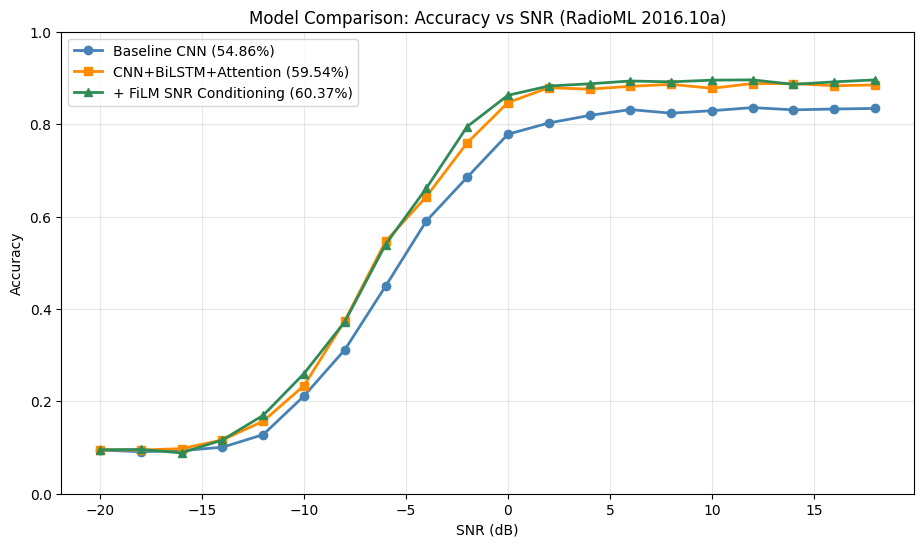

In [9]:
results_film = {
    'unique_snrs': [int(s) for s in unique_snrs],
    'snr_accuracies': [float(a) for a in snr_accuracies_film],
    'overall_test_acc': float(overall_test_acc)
}

with open('../results/snr_aware_film_results.json', 'w') as f:
    json.dump(results_film, f, indent=2)

with open('../results/baseline_cnn_results.json', 'r') as f:
    r_base = json.load(f)
with open('../results/bilstm_attention_results.json', 'r') as f:
    r_bilstm = json.load(f)

plt.figure(figsize=(11, 6))
plt.plot(r_base['unique_snrs'], r_base['snr_accuracies'], marker='o', linewidth=2,
         label=f"Baseline CNN ({r_base['overall_test_acc']*100:.2f}%)", color='steelblue')
plt.plot(r_bilstm['unique_snrs'], r_bilstm['snr_accuracies'], marker='s', linewidth=2,
         label=f"CNN+BiLSTM+Attention ({r_bilstm['overall_test_acc']*100:.2f}%)", color='darkorange')
plt.plot(results_film['unique_snrs'], results_film['snr_accuracies'], marker='^', linewidth=2,
         label=f"+ FiLM SNR Conditioning ({overall_test_acc*100:.2f}%)", color='seagreen')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy')
plt.title('Model Comparison: Accuracy vs SNR (RadioML 2016.10a)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.savefig('../results/comparison_all_three.png', dpi=300, bbox_inches='tight')
plt.show()